# Advanced EDA — Thai Constitution Data

In [1]:
import ast
import warnings
from collections import Counter

import ipywidgets as widgets
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

font_path = '../../static/font/LINESeedSansTH_Rg.ttf'
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

## 0. Data Loading

In [2]:
df = pd.read_csv("../../data/preprocessed_data.csv")
df['tokens'] = df['tokens'].apply(ast.literal_eval)
df['text_length'] = df['text'].str.len()

# Historical era labels
def assign_era(year):
    if year <= 2488:
        return '1. Pre-WWII\n(2475–2488)'
    elif year <= 2516:
        return '2. Cold War\n(2490–2516)'
    elif year <= 2543:
        return '3. Democracy Era\n(2517–2543)'
    else:
        return '4. Modern\n(2544–2564)'

df['era'] = df['year_th'].apply(assign_era)

# Interim flag (from name_short)
df['is_interim'] = df['name_short'].str.contains('interim', case=False)

# Ordered list of constitutions by year
const_order = (
    df[['name_short', 'year_th']]
    .drop_duplicates()
    .sort_values('year_th')['name_short']
    .tolist()
)

print(f"Loaded {len(df)} rows | {df['name_short'].nunique()} constitutions")
df.head(3)

Loaded 4706 rows | 38 constitutions


,constitution_id,year_th,name_short,chapter_number,section_number,text,tokens,word_count,text_length,era,is_interim
0,const_2475,2475,2475,0,1,สยามประเทศเป็นราชอาณาจักรอันหนึ่งอันเดียว จะแบ...,"[สยาม, ประเทศ, ราชอาณาจักร, แบ่งแยก, ประชาชน, ...",12,146,1. Pre-WWII\n(2475–2488),False
1,const_2475,2475,2475,0,2,อำนาจอธิปไตยย่อมมาจากปวงชนชาวสยาม พระมหากษัตริ...,"[อำนาจ, อธิปไตย, ปวง, ชน, สยาม, พระมหากษัตริย์...",11,109,1. Pre-WWII\n(2475–2488),False
2,const_2475,2475,2475,1,3,องค์พระมหากษัตริย์ดำรงอยู่ในฐานะอันเป็นที่เคาร...,"[องค์, พระมหากษัตริย์, ดำรง, ฐานะ, เคารพ, สัก,...",8,72,1. Pre-WWII\n(2475–2488),False


In [23]:
df[df["chapter_number"] == 1 & (df["constitution_id"] == "const_2475")]["section_number"].value_counts()

section_number
211    69
95     33
3      32
1      32
2      32
       ..
281     1
210     1
212     1
229     1
231     1
Name: count, Length: 289, dtype: int64

## 1. Chapter Structure Heatmap

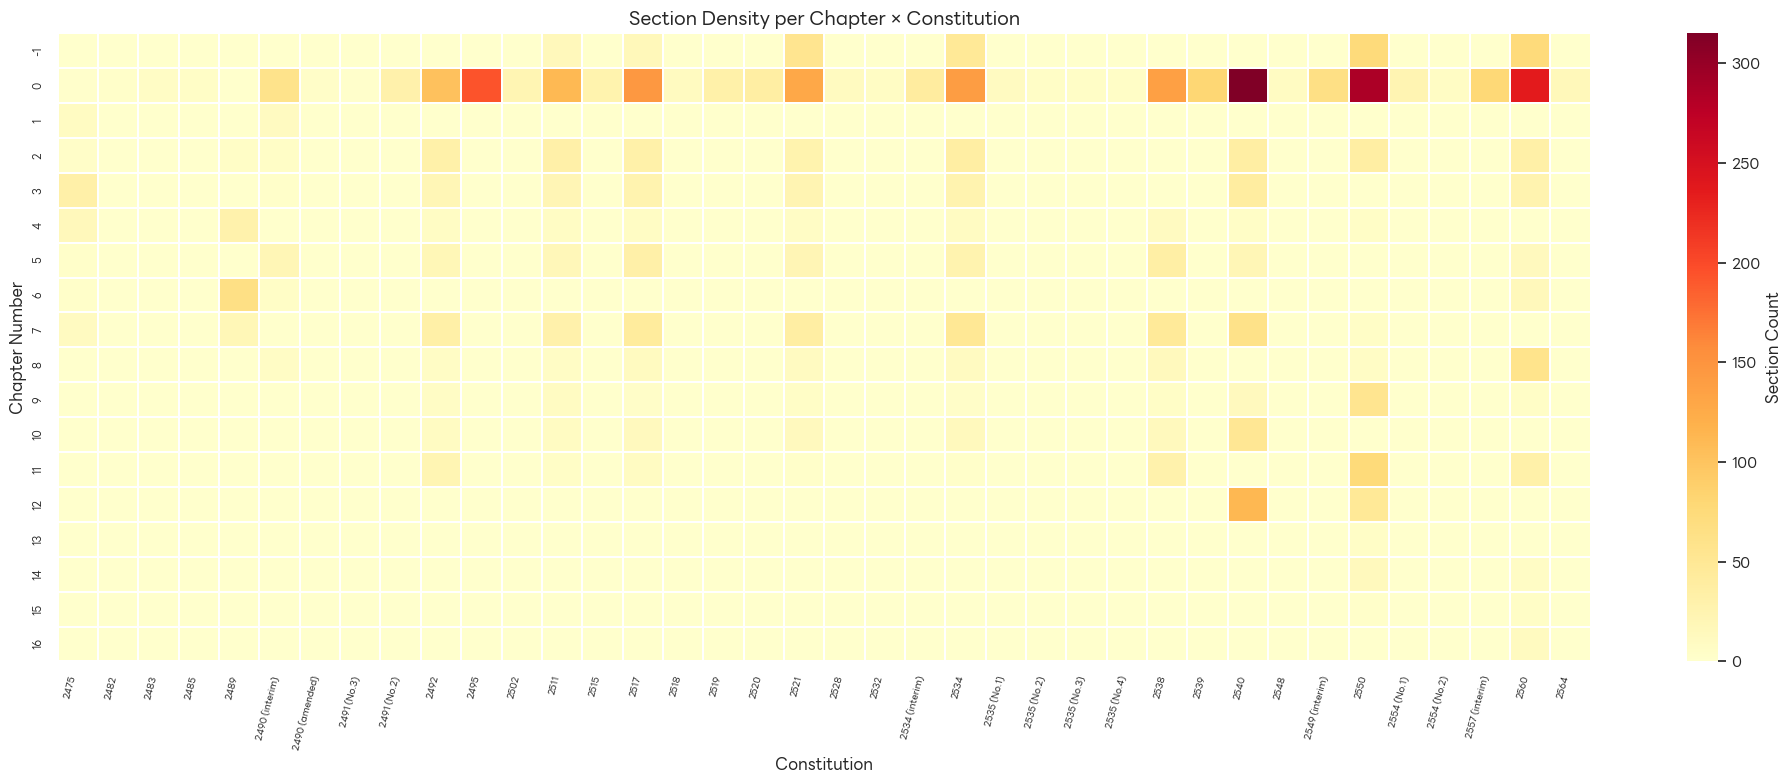

In [3]:
# Section density: chapter_number × constitution
pivot = (
    df.groupby(['name_short', 'chapter_number'])
    .size()
    .reset_index(name='section_count')
    .pivot(index='chapter_number', columns='name_short', values='section_count')
    .reindex(columns=const_order)
    .fillna(0)
    .astype(int)
)

plt.figure(figsize=(20, 8))
sns.heatmap(
    pivot,
    cmap='YlOrRd',
    linewidths=0.3,
    cbar_kws={'label': 'Section Count'},
    annot=False
)
plt.title('Section Density per Chapter × Constitution', fontsize=14)
plt.xlabel('Constitution')
plt.ylabel('Chapter Number')
plt.xticks(rotation=75, ha='right', fontsize=7)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

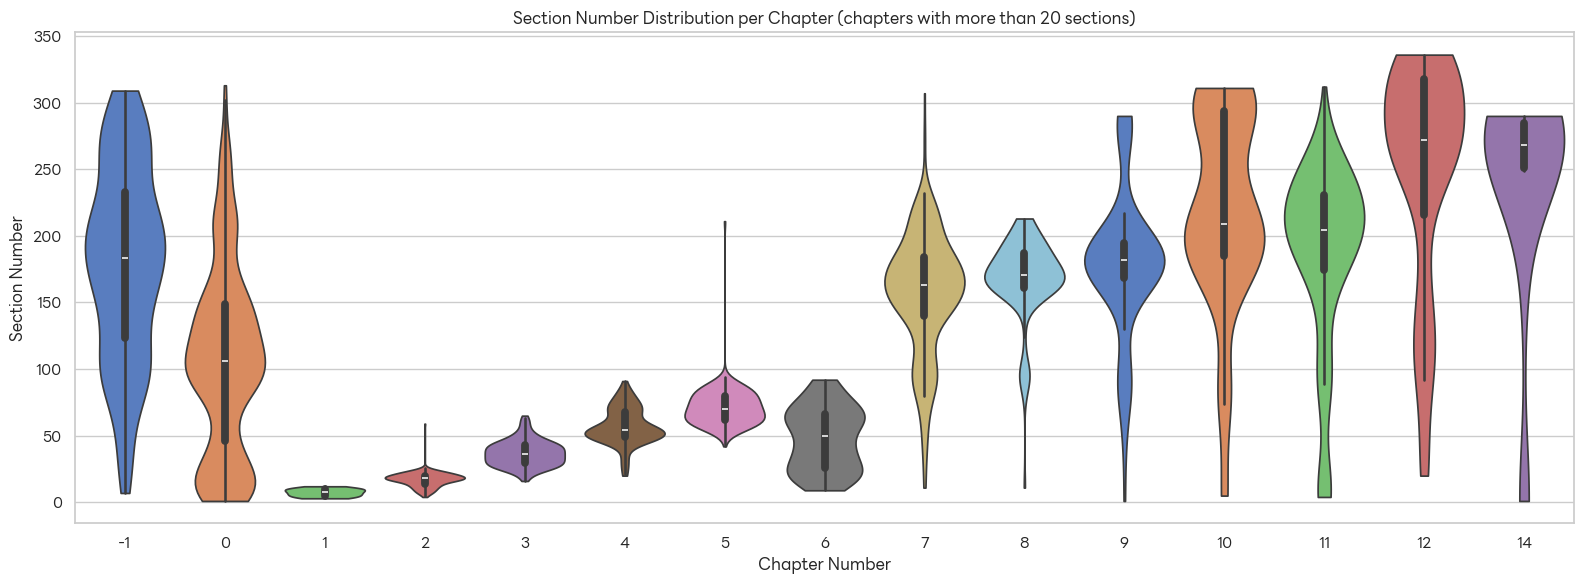

In [27]:
# Violin plot — section_number spread per chapter (how far section numbers reach per chapter)
# Filter to chapters with enough data
chapter_counts = df['chapter_number'].value_counts()
chapters_to_show = chapter_counts[chapter_counts >= 20].index.tolist()
df_chap = df[df['chapter_number'].isin(chapters_to_show)]

plt.figure(figsize=(16, 6))
sns.violinplot(
    x='chapter_number',
    y='section_number',
    data=df_chap,
    order=sorted(chapters_to_show),
    palette='muted',
    inner='box',
    cut=0
)
plt.title('Section Number Distribution per Chapter (chapters with more than 20 sections)')
plt.xlabel('Chapter Number')
plt.ylabel('Section Number')
plt.tight_layout()
plt.show()

## 2. Era Comparison

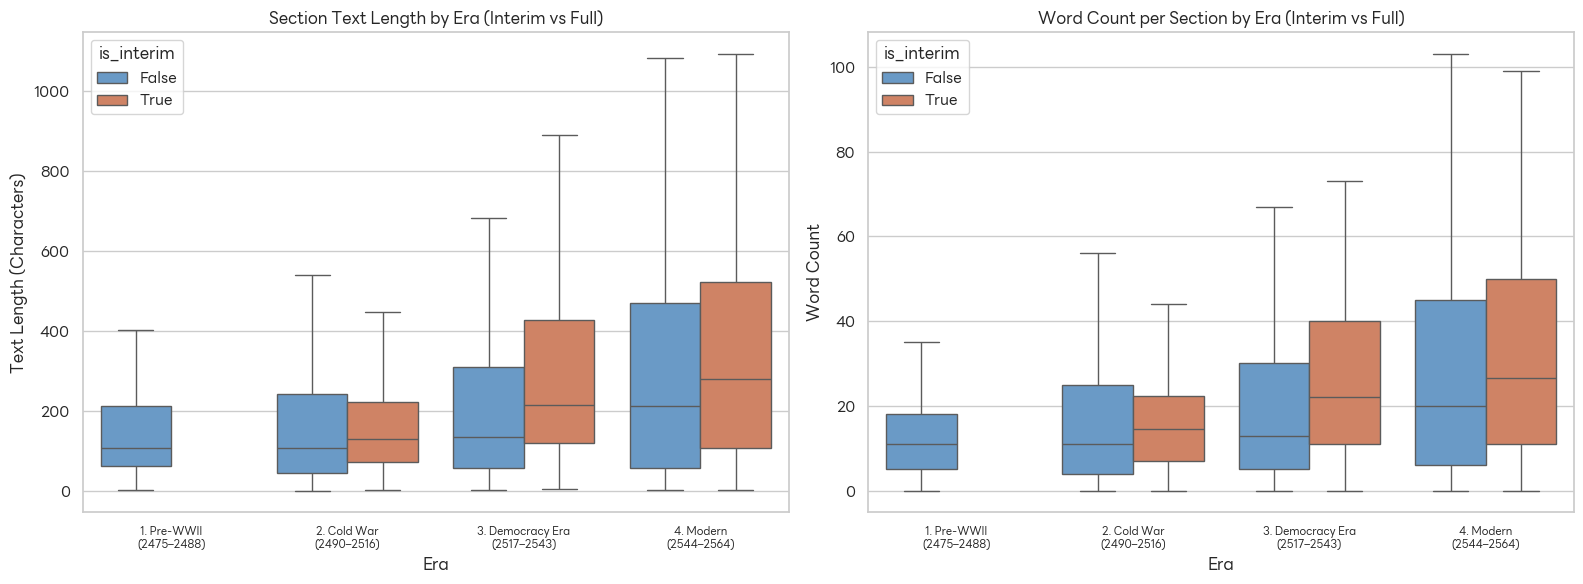

In [15]:
# Box plot — section text length by historical era, split by interim vs full
era_order = sorted(df['era'].unique())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    x='era', y='text_length', hue='is_interim',
    data=df, order=era_order,
    palette={True: '#e07b54', False: '#5b9bd5'},
    showfliers=False, ax=axes[0]
)
axes[0].set_title('Section Text Length by Era (Interim vs Full)')
axes[0].set_xlabel('Era')
axes[0].set_ylabel('Text Length (Characters)')
axes[0].tick_params(axis='x', labelsize=8)

sns.boxplot(
    x='era', y='word_count', hue='is_interim',
    data=df, order=era_order,
    palette={True: '#e07b54', False: '#5b9bd5'},
    showfliers=False, ax=axes[1]
)
axes[1].set_title('Word Count per Section by Era (Interim vs Full)')
axes[1].set_xlabel('Era')
axes[1].set_ylabel('Word Count')
axes[1].tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.show()

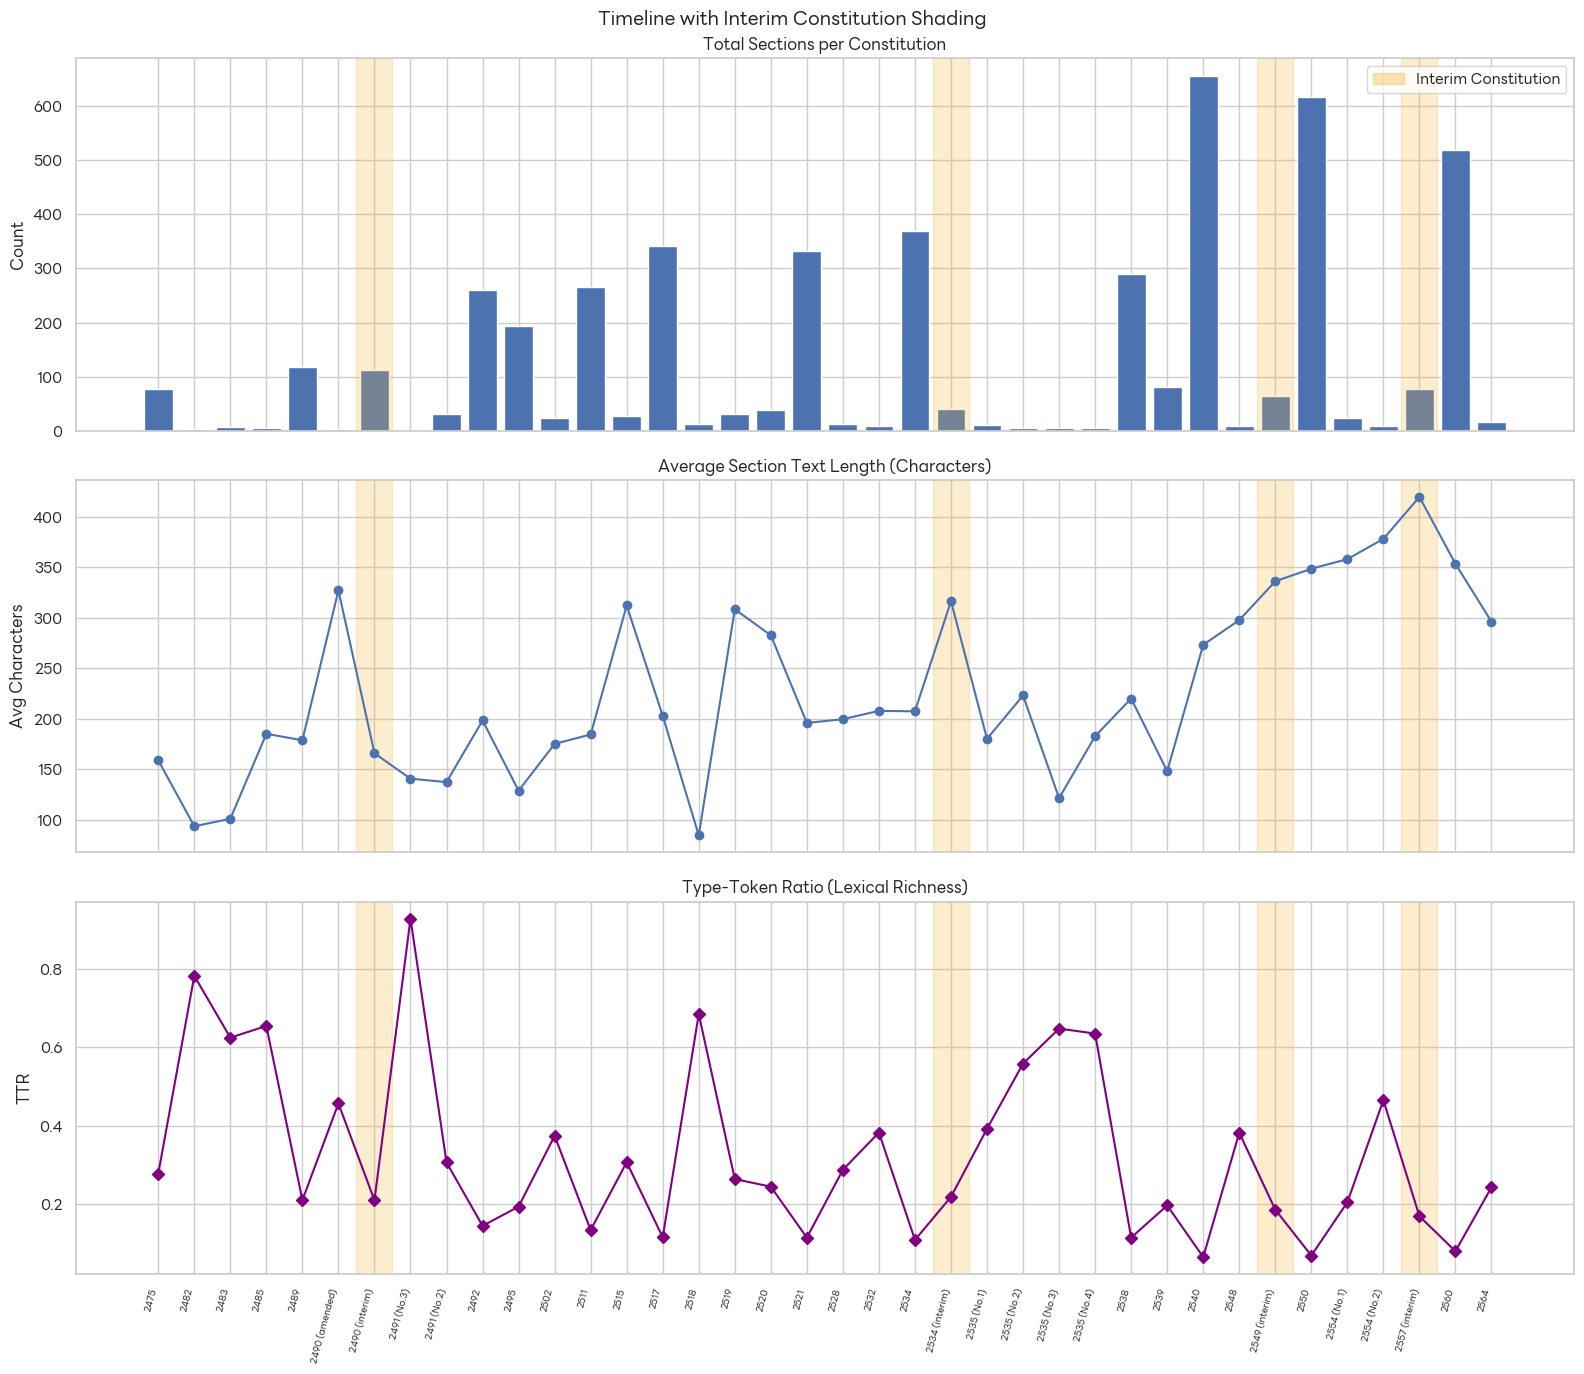

In [6]:
# Timeline charts with axvspan shading for interim constitutions
timeline_df = (
    df.groupby(['name_short', 'year_th', 'is_interim'])
    .agg(
        total_sections=('text', 'count'),
        avg_text_length=('text_length', 'mean'),
        avg_word_count=('word_count', 'mean'),
        total_unique_words=('tokens', lambda x: len({tok for toks in x for tok in toks})),
        total_words=('tokens', lambda x: sum(len(toks) for toks in x)),
    )
    .reset_index()
    .sort_values('year_th')
)
timeline_df['ttr'] = timeline_df['total_unique_words'] / timeline_df['total_words']

x_labels = timeline_df['name_short'].tolist()
x_pos = range(len(x_labels))
interim_positions = [i for i, r in enumerate(timeline_df.itertuples()) if r.is_interim]

def shade_interim(ax):
    for i in interim_positions:
        ax.axvspan(i - 0.5, i + 0.5, color='#f4b942', alpha=0.25)

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

axes[0].bar(x_pos, timeline_df['total_sections'])
shade_interim(axes[0])
axes[0].set_title('Total Sections per Constitution')
axes[0].set_ylabel('Count')

axes[1].plot(x_pos, timeline_df['avg_text_length'], marker='o')
shade_interim(axes[1])
axes[1].set_title('Average Section Text Length (Characters)')
axes[1].set_ylabel('Avg Characters')

axes[2].plot(x_pos, timeline_df['ttr'], marker='D', color='purple')
shade_interim(axes[2])
axes[2].set_title('Type-Token Ratio (Lexical Richness)')
axes[2].set_ylabel('TTR')

for ax in axes:
    ax.set_xticks(list(x_pos))
    ax.set_xticklabels(x_labels, rotation=75, ha='right', fontsize=7)

interim_patch = mpatches.Patch(color='#f4b942', alpha=0.4, label='Interim Constitution')
axes[0].legend(handles=[interim_patch], loc='upper right')

plt.suptitle('Timeline with Interim Constitution Shading', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Vocabulary Evolution

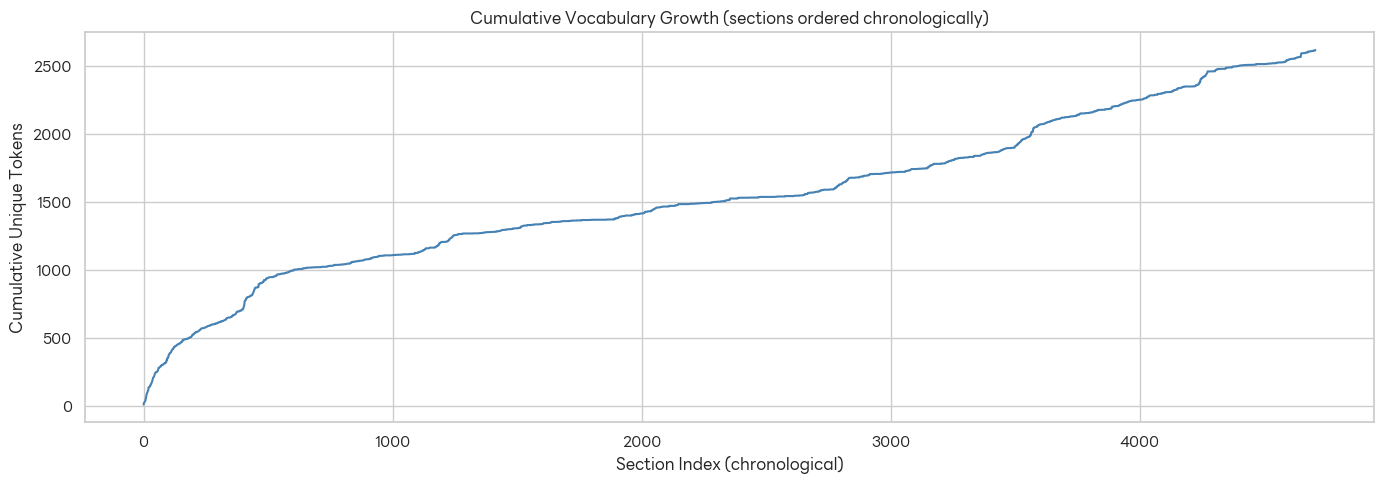

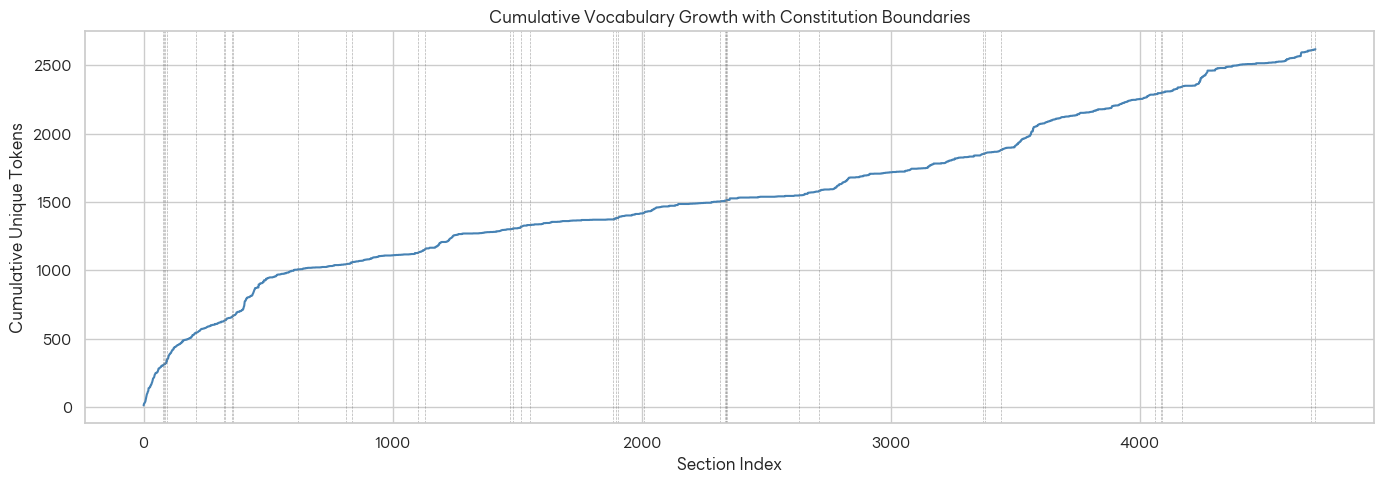

In [7]:
# Cumulative vocabulary growth — unique tokens as sections are added chronologically
df_sorted = df.sort_values(['year_th', 'section_number']).reset_index(drop=True)

seen = set()
cumulative_vocab = []
for tokens in df_sorted['tokens']:
    seen.update(tokens)
    cumulative_vocab.append(len(seen))

plt.figure(figsize=(14, 5))
plt.plot(cumulative_vocab, linewidth=1.5, color='steelblue')
plt.title('Cumulative Vocabulary Growth (sections ordered chronologically)')
plt.xlabel('Section Index (chronological)')
plt.ylabel('Cumulative Unique Tokens')
plt.tight_layout()
plt.show()

# Annotate constitution boundaries
const_boundaries = df_sorted.groupby('name_short', sort=False).apply(lambda g: g.index[-1]).to_dict()
plt.figure(figsize=(14, 5))
plt.plot(cumulative_vocab, linewidth=1.5, color='steelblue')
for name, idx in const_boundaries.items():
    plt.axvline(x=idx, color='gray', linewidth=0.5, linestyle='--', alpha=0.6)
plt.title('Cumulative Vocabulary Growth with Constitution Boundaries')
plt.xlabel('Section Index')
plt.ylabel('Cumulative Unique Tokens')
plt.tight_layout()
plt.show()

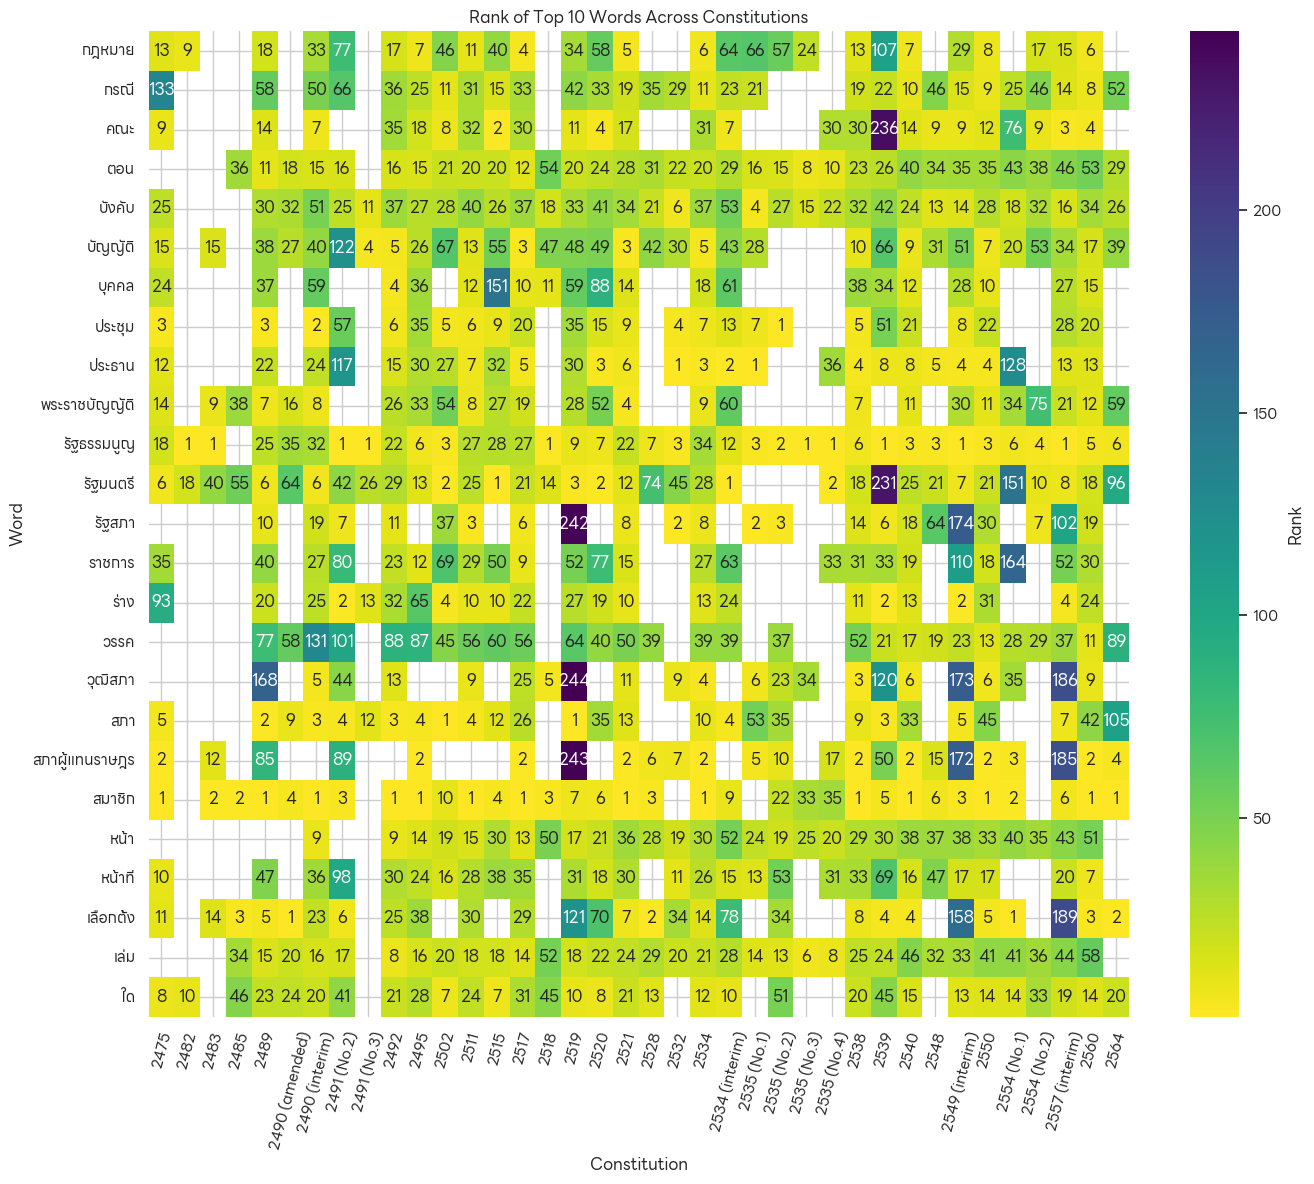

In [ ]:
# Bump chart — rank of top 10 words per constitution over time
top_words_global = [w for w, _ in Counter(
    tok for toks in df['tokens'] for tok in toks
).most_common(25)]

# Compute rank of each top word per constitution
rank_data = []
for name in const_order:
    tokens_flat = [tok for toks in df[df['name_short'] == name]['tokens'] for tok in toks]
    freq = Counter(tokens_flat)
    sorted_words = [w for w, _ in freq.most_common()]
    for word in top_words_global:
        rank = sorted_words.index(word) + 1 if word in sorted_words else None
        rank_data.append({'constitution': name, 'word': word, 'rank': rank})

rank_df = pd.DataFrame(rank_data).dropna()

pivot = rank_df.pivot(index="word", columns="constitution", values="rank")

plt.figure(figsize=(14, 12))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="viridis_r", cbar_kws={'label': 'Rank'})
plt.title("Rank of Top 10 Words Across Constitutions")
plt.xlabel("Constitution")
plt.ylabel("Word")
plt.xticks(rotation=75,)
plt.tight_layout()
plt.show()

In [11]:
# KWIC Explorer — search a keyword and display ±5 token context
def kwic_search(keyword, window=5, max_results=30):
    keyword = keyword.strip()
    if not keyword:
        print('Enter a keyword.')
        return

    results = []
    for _, row in df.iterrows():
        toks = row['tokens']
        for i, tok in enumerate(toks):
            if tok == keyword:
                left = ' '.join(toks[max(0, i - window):i])
                right = ' '.join(toks[i + 1:i + 1 + window])
                results.append({
                    'Constitution': row['name_short'],
                    'Section': row['section_number'],
                    'Left Context': left,
                    'Keyword': tok,
                    'Right Context': right,
                })
                if len(results) >= max_results:
                    break
        if len(results) >= max_results:
            break

    if not results:
        print(f'No matches found for "{keyword}".')
        return

    result_df = pd.DataFrame(results)
    print(f'Found {len(result_df)} occurrence(s) for "{keyword}" (showing up to {max_results}):')
    display(result_df)

kwic_input = widgets.Text(
    placeholder='Type a Thai word...',
    description='Keyword:',
    layout=widgets.Layout(width='300px')
)
widgets.interactive(kwic_search, keyword=kwic_input)

interactive(children=(Text(value='', description='Keyword:', layout=Layout(width='300px'), placeholder='Type a…

## 4. Rare Word Analysis

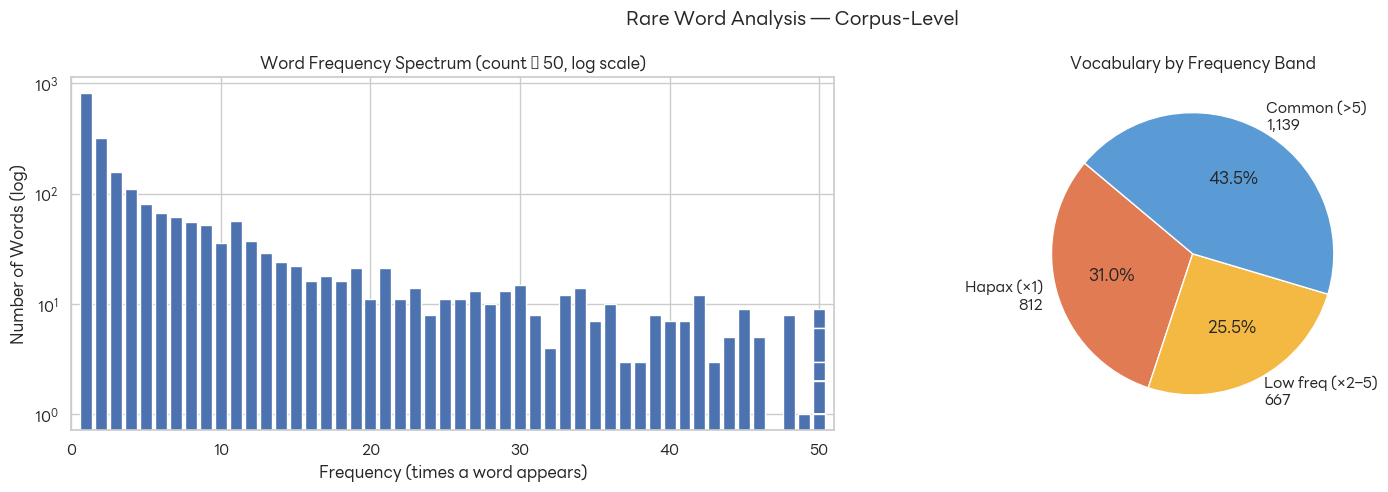

Total unique words: 2,618
Hapax legomena (appear only once): 812 (31.0%)


In [41]:
# Global token frequency
all_tokens_flat = [tok for toks in df['tokens'] for tok in toks]
global_freq = Counter(all_tokens_flat)
freq_df = pd.DataFrame(global_freq.most_common(), columns=['word', 'count'])

# Rare = appears in only 1 constitution (hapax constitutionaux)
word_const_count = (
    df.explode('tokens')
    .dropna(subset=['tokens'])
    .groupby('tokens')['name_short']
    .nunique()
    .reset_index()
    .rename(columns={'tokens': 'word', 'name_short': 'n_constitutions'})
)

freq_df = freq_df.merge(word_const_count, on='word')

# Frequency spectrum — how many words appear exactly N times
freq_spectrum = (
    freq_df['count']
    .value_counts()
    .sort_index()
    .rename_axis('frequency')
    .reset_index(name='num_words')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: log-scale spectrum
axes[0].bar(freq_spectrum['frequency'].clip(upper=50), freq_spectrum['num_words'], width=0.8)
axes[0].set_yscale('log')
axes[0].set_title('Word Frequency Spectrum (count ≤ 50, log scale)')
axes[0].set_xlabel('Frequency (times a word appears)')
axes[0].set_ylabel('Number of Words (log)')
axes[0].set_xlim(0, 51)

# Right: pie of rare vs common
rare_1 = (freq_df['count'] == 1).sum()
rare_2_5 = ((freq_df['count'] >= 2) & (freq_df['count'] <= 5)).sum()
common = (freq_df['count'] > 5).sum()
axes[1].pie(
    [rare_1, rare_2_5, common],
    labels=[f'Hapax (×1)\n{rare_1:,}', f'Low freq (×2–5)\n{rare_2_5:,}', f'Common (>5)\n{common:,}'],
    autopct='%1.1f%%',
    colors=['#e07b54', '#f4b942', '#5b9bd5'],
    startangle=140
)
axes[1].set_title('Vocabulary by Frequency Band')

plt.suptitle('Rare Word Analysis — Corpus-Level', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Total unique words: {len(freq_df):,}")
print(f"Hapax legomena (appear only once): {rare_1:,} ({rare_1/len(freq_df)*100:.1f}%)")

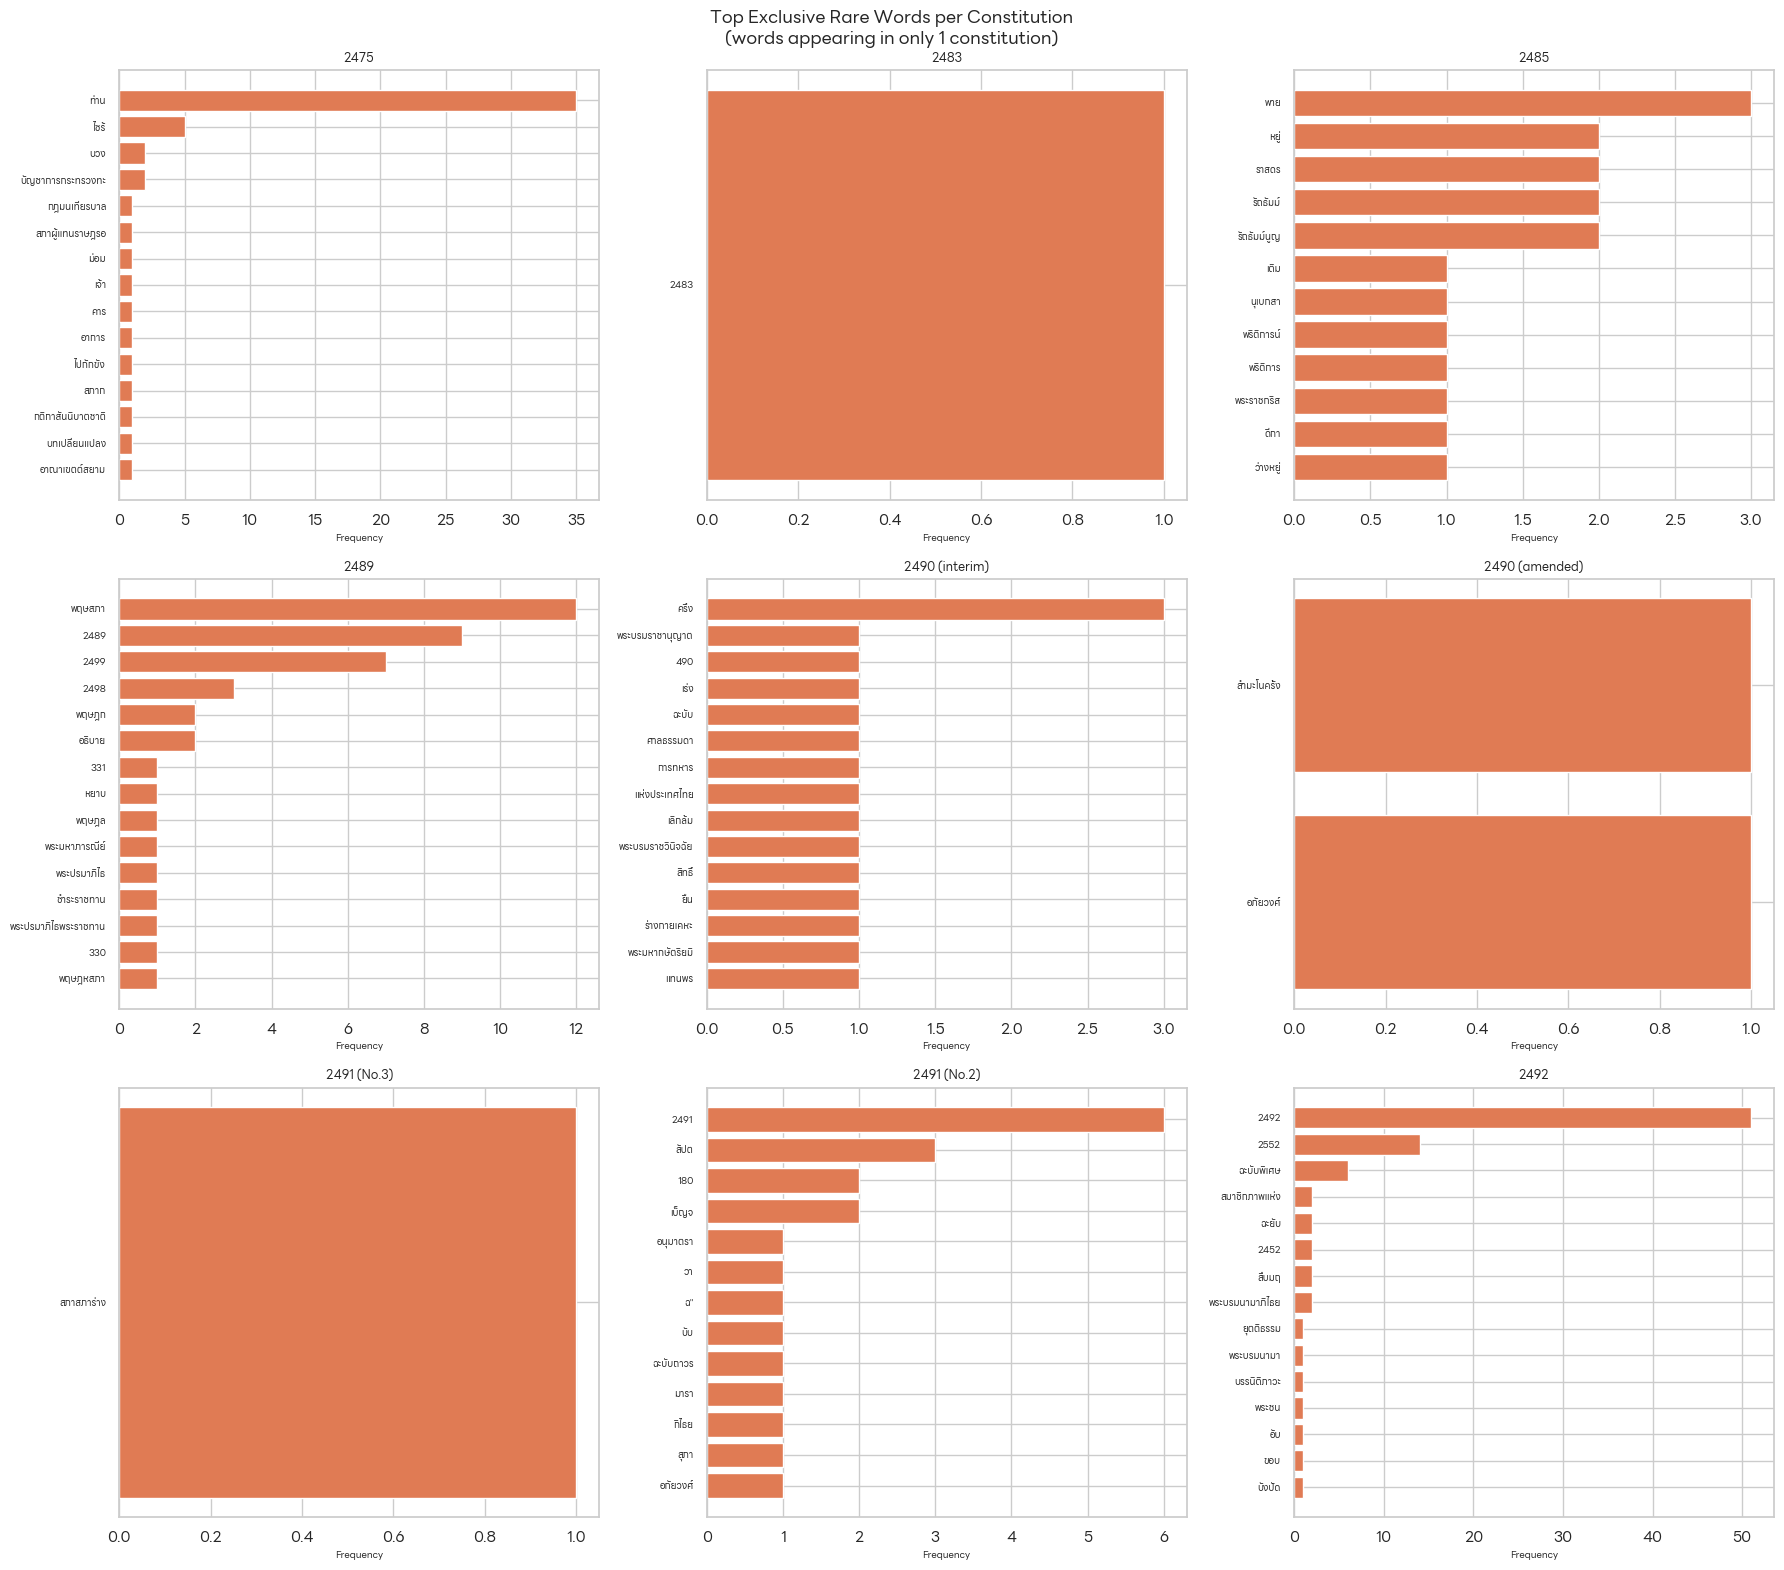

In [44]:
# Rare words exclusive to a single constitution — top 15 per constitution (sample)
exclusive_words = freq_df[freq_df['n_constitutions'] == 1].copy()

# Map each exclusive word back to its constitution
word_to_const = (
    df.explode('tokens')
    .dropna(subset=['tokens'])
    .drop_duplicates(subset=['tokens', 'name_short'])
    [['tokens', 'name_short']]
    .rename(columns={'tokens': 'word'})
)
exclusive_words = exclusive_words.merge(word_to_const, on='word')

# Top 15 rarest exclusive words per constitution (by raw count)
top_exclusive = (
    exclusive_words
    .sort_values('count', ascending=False)
    .groupby('name_short')
    .head(15)
)

# Plot for first 9 constitutions in chronological order
sample_consts = [c for c in const_order if c in top_exclusive['name_short'].unique()][:9]

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes = axes.flatten()

for ax, name in zip(axes, sample_consts):
    sub = top_exclusive[top_exclusive['name_short'] == name].head(15)
    ax.barh(sub['word'][::-1], sub['count'][::-1], color='#e07b54')
    ax.set_title(name, fontsize=9)
    ax.tick_params(axis='y', labelsize=7)
    ax.set_xlabel('Frequency', fontsize=7)

plt.suptitle('Top Exclusive Rare Words per Constitution\n(words appearing in only 1 constitution)', fontsize=13)
plt.tight_layout()
plt.show()

In [43]:
# Interactive: explore exclusive rare words for any constitution
def plot_rare_words(constitution, top_n=20):
    sub = top_exclusive[top_exclusive['name_short'] == constitution].head(top_n)
    if sub.empty:
        print(f'No exclusive rare words found for {constitution}.')
        return
    plt.figure(figsize=(10, max(4, top_n * 0.35)))
    plt.barh(sub['word'][::-1], sub['count'][::-1], color='#e07b54')
    plt.title(f'Exclusive Rare Words — {constitution}')
    plt.xlabel('Frequency in this constitution')
    plt.tight_layout()
    plt.show()

rare_dropdown = widgets.Dropdown(
    options=[c for c in const_order if c in top_exclusive['name_short'].unique()],
    description='Constitution:',
    layout=widgets.Layout(width='300px')
)
widgets.interactive(plot_rare_words, constitution=rare_dropdown, top_n=widgets.IntSlider(
    value=15, min=5, max=30, step=5, description='Top N:', continuous_update=False
))

interactive(children=(Dropdown(description='Constitution:', layout=Layout(width='300px'), options=('2475', '24…